# HGND Reconstruction GNN — Preprocessing & Training

Thin driver notebook. All heavy lifting lives in the `HGNDRecoGNN` package:

- `HGNDRecoGNN.data.graph_dataset` — CSV → graph shards (schema v2 adds virtual `events`/`sides` node types for hetero models)
- `HGNDRecoGNN.models.default_net` — the current Net (extracted from cell 11 of the pre-refactor notebook)
- `HGNDRecoGNN.training` — `fit()` + `predict()`, called identically from notebook and `scripts/train.py`
- `HGNDRecoGNN.device` — CUDA → MPS → CPU auto-detection with per-submodule pinning

Interactive knobs stay in this notebook; the code paths are exercised the same way from `sbatch slurm/train.sbatch` on the cluster.

In [1]:
import os, sys, time, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# Put the package on sys.path so `import HGNDRecoGNN` works when the
# notebook is launched from anywhere.
PACKAGE_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PACKAGE_ROOT not in sys.path:
    sys.path.insert(0, PACKAGE_ROOT)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

print(f'PyTorch {torch.__version__}   PyG {torch_geometric.__version__}')
print(f'sys.path package root: {PACKAGE_ROOT}')

PyTorch 2.7.1   PyG 2.7.0
sys.path package root: /Users/vovvy/Project/BM@N/HGND


## 1. Import package modules

In [2]:
from HGNDRecoGNN.data.graph_dataset import HGNDGraphDataset, FEATURES, SCHEMA_V
from HGNDRecoGNN import device as device_mod
from HGNDRecoGNN.models import build_default_net
from HGNDRecoGNN.training import TrainConfig, fit, predict, LossWeights
from HGNDRecoGNN.training.train import build_loaders
from HGNDRecoGNN.training.eval import save_predictions

print(f'Schema v{SCHEMA_V}  Features: {FEATURES}')

Schema v2  Features: ['fX', 'fY', 'fZ', 'LayerId', 'RowId', 'ColumnId', 'fTime', 'fELoss', 'eToF', 'SurfaceHit']


## 2. Configure dataset & run parameters

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────
DATASET_NAME = 'defaultSpot'                                # zeroSpot | defaultSpot | bigSpot
HITS_CSV_DIR = os.path.join(PROJECT_ROOT, 'data',
                            f'smash_xecs_2.87gev_hardSkyrme_{DATASET_NAME}')
DATASET_ROOT = os.path.join(os.getcwd(), 'cache',
                            f'ndet_dataset_smash_{DATASET_NAME}')

# ── Graph construction ────────────────────────────────────────────
RLOCAL, TWINDOW, SHARD_SIZE, NUM_WORKERS_PROCESS = 3.6, 1.5, 1024, 8

# ── Device (auto = CUDA > MPS > CPU) ──────────────────────────────
DEVICE = 'auto'
_DEV   = device_mod.detect()
_DEF   = device_mod.safe_defaults(_DEV)
_AVAIL = device_mod.available_memory_gb(_DEV)
print(f'device={_DEV}  available_mem={_AVAIL:.1f} GB  ({_DEF.note})')

# ── Event / shard caps (None = all) ───────────────────────────────
# NUM_SHARDS caps the number of on-disk shards exposed to training.
# Preloading is further capped by PRELOAD_MAX_GB below.
MAX_EVENTS = 100_000
NUM_SHARDS = _DEF.max_preload_shards

# ── Training ──────────────────────────────────────────────────────
# Batch, hidden width, and depth are tuned per device; override any of
# these by editing this cell after inspecting `_DEF`.
BATCH_SIZE       = _DEF.batch_size
HIDDEN_CHANNELS  = _DEF.hidden_channels
NUM_LAYERS       = _DEF.num_layers
EPOCHS           = 20
SEED             = 42

# ── Preload budget ────────────────────────────────────────────────
# Leave headroom for the model + activations. On MPS the accelerator
# shares RAM with the preloaded dataset, so this must be well under
# total memory. On CUDA the dataset lives in host RAM only.
if _DEV == 'mps':
    PRELOAD_MAX_GB = max(2.0, _AVAIL * 0.30)
elif _DEV == 'cuda':
    PRELOAD_MAX_GB = max(4.0, _AVAIL * 0.60)
else:
    PRELOAD_MAX_GB = max(2.0, _AVAIL * 0.40)
print(f'preload budget: {PRELOAD_MAX_GB:.1f} GB   '
      f'batch={BATCH_SIZE}  hidden={HIDDEN_CHANNELS}  layers={NUM_LAYERS}  '
      f'num_shards={NUM_SHARDS}')


## 3. Build (or load) the sharded dataset

In [ ]:
import shutil, json as _json

# ── Schema policy ─────────────────────────────────────────────────
# Existing v1 shards on disk lack the v2 events/sides node types.
# ALLOW_STALE_SCHEMA=True keeps those shards — safe for net_default only.
# Set False (or delete cache/) when using hetero_* / thesis_* / spectral_*
# models, which need v2.
ALLOW_STALE_SCHEMA = True
FORCE_REBUILD      = False    # True → wipe processed/ and start over

processed_dir = os.path.join(DATASET_ROOT, 'processed')
meta_path     = os.path.join(processed_dir, 'meta.json')

if FORCE_REBUILD and os.path.exists(processed_dir):
    print(f'FORCE_REBUILD: removing {processed_dir}')
    shutil.rmtree(processed_dir)
elif os.path.exists(meta_path):
    with open(meta_path) as f:
        _m = _json.load(f)
    _v = _m.get('schema_version', 1)
    print(f'Existing dataset: {_m["num_graphs"]} graphs / {_m["num_shards"]} shards '
          f'(schema v{_v})')
    if _v != SCHEMA_V and not ALLOW_STALE_SCHEMA:
        print(f'  → v{_v} != code v{SCHEMA_V}. Will reprocess to rebuild.')

t0 = time.time()
dataset = HGNDGraphDataset(
    root=DATASET_ROOT,
    hits_csv_dir=HITS_CSV_DIR,
    rlocal=RLOCAL, twindow=TWINDOW,
    num_workers=NUM_WORKERS_PROCESS, shard_size=SHARD_SIZE,
    max_events=MAX_EVENTS, num_shards=NUM_SHARDS,
    allow_stale_schema=ALLOW_STALE_SCHEMA,
)
print(f'Dataset ready: {len(dataset)} graphs   ({time.time() - t0:.1f}s)')

# Preload with a hard memory ceiling — on MPS/unified memory, an
# unbounded preload will silently OOM the kernel. `max_gb` trims the
# shard count if the probe suggests it would exceed the budget.
dataset.preload(max_gb=PRELOAD_MAX_GB)


## 4. Inspect a graph & summary stats

In [5]:
g = dataset[0]
print(g)
print(f'\nhits:     {g["hits"].x.shape[0]} nodes x {g["hits"].x.shape[1]} features')
print(f'edges:    {g["hits","hits"].edge_index.shape[1]}')
print(f'clusters: {g["clusters"].x.shape[0]}')
if 'events' in g.node_types:
    print(f'events:   {g["events"].x.shape[0]}    sides: {g["sides"].x.shape[0]}   (schema v2)')
else:
    print('events/sides: absent (schema v1 shards — rebuild for hetero_* models)')
print(f'istop:    {g.istop.item()}    Row: {g.Row.item()}    evtlabel: {g.evtlabel.item()}')

HeteroData(
  true_links=[1],
  cluster=[1, 1],
  cllabel=[1],
  clenergy=[1],
  Row=0,
  istop=[1],
  evtlabel=0.0,
  hits={
    x=[1, 10],
    pos=[1, 3],
    y=[1],
  },
  clusters={
    x=[1, 1],
    y=[1],
    connection_mask=[1],
  },
  (hits, to, hits)={ edge_index=[2, 1] },
  (clusters, to, clusters)={ edge_index=[2, 1] }
)

hits:     1 nodes x 10 features
edges:    1
clusters: 1
events/sides: absent (schema v1 shards — rebuild for hetero_* models)
istop:    True    Row: 0    evtlabel: 0.0


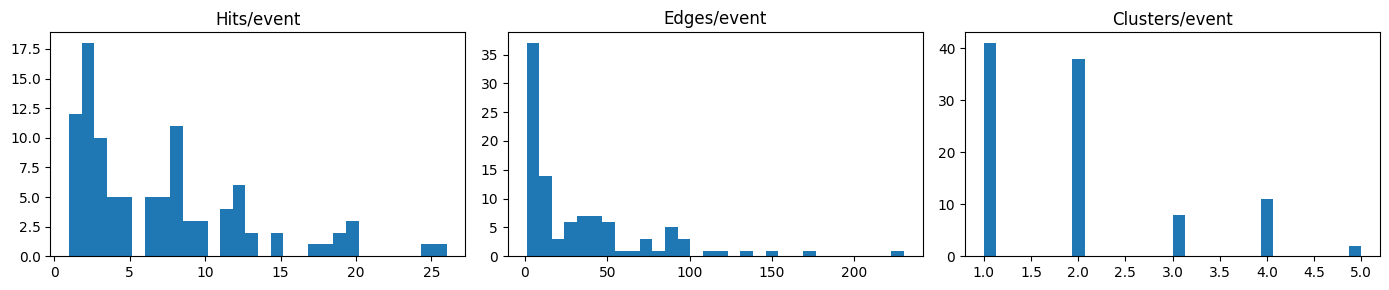

In [6]:
n_hits, n_edges, n_clusters = [], [], []
for i in range(min(100, len(dataset))):
    gi = dataset[i]
    n_hits.append(gi['hits'].x.shape[0])
    n_edges.append(gi['hits', 'hits'].edge_index.shape[1])
    n_clusters.append(gi['clusters'].x.shape[0])

fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].hist(n_hits, bins=30);     ax[0].set_title('Hits/event')
ax[1].hist(n_edges, bins=30);    ax[1].set_title('Edges/event')
ax[2].hist(n_clusters, bins=30); ax[2].set_title('Clusters/event')
plt.tight_layout(); plt.show()

## 5. Round-trip integrity check

In [7]:
g_mem  = dataset[0]
shard0 = torch.load(os.path.join(dataset.processed_dir, 'shard_0.pt'),
                    weights_only=False)
g_disk = shard0[0]
assert torch.equal(g_mem['hits'].x, g_disk['hits'].x)
assert torch.equal(g_mem['hits', 'hits'].edge_index,
                   g_disk['hits', 'hits'].edge_index)
assert torch.equal(g_mem['clusters'].y, g_disk['clusters'].y)
assert torch.equal(g_mem.true_links, g_disk.true_links)
print(f'✓ shard 0 has {len(shard0)} graphs — round-trip ok')

✓ shard 0 has 1024 graphs — round-trip ok


## 6. Loaders, model, training

In [ ]:
cfg = TrainConfig(
    batch_size=BATCH_SIZE, seed=SEED, train_frac=0.5,
    epochs=EPOCHS, lr=1e-3, weight_decay=1e-5,
    device=DEVICE,
    num_workers_loader=_DEF.num_workers_loader,
    arch_name='net_default',
    arch_kwargs={'hidden_channels': HIDDEN_CHANNELS, 'num_layers': NUM_LAYERS},
    checkpoint_dir=os.path.join(os.getcwd(), 'checkpoints'),
    checkpoint_name=f'{DATASET_NAME}_net_default.pt',
    loss_weights=LossWeights(),
)

train_loader, test_loader = build_loaders(dataset, cfg)
print(f'Train: {len(train_loader.dataset)}   Test: {len(test_loader.dataset)}')

model = build_default_net(dataset,
                          hidden_channels=cfg.arch_kwargs['hidden_channels'],
                          num_layers=cfg.arch_kwargs['num_layers'])
plan  = device_mod.plan_for(model, cfg.device, cfg.cpu_pinned)
device_mod.to_device(model, plan)
print(device_mod.summarize(plan))
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')


In [9]:
result = fit(model, train_loader, test_loader, cfg, plan=plan)

plt.figure(figsize=(8, 4))
plt.plot(result['train_loss'], label='train')
plt.plot(result['val_loss'],   label='val')
plt.axvline(result['best_epoch'], ls=':', c='k', label=f'best epoch {result["best_epoch"]}')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()
print(f'checkpoint: {result["checkpoint_path"]}')

fit(): device=mps  cpu_pinned=[cluster_conv_cpu]  epochs=20  batch=512  lr=0.001


eval: 100%|██████████| 100/100 [02:46<00:00,  1.66s/it]


epoch 000  train 47.0298  val 3.2177  lr 1.00e-03  [best]


eval: 100%|██████████| 100/100 [02:11<00:00,  1.31s/it]


epoch 001  train 2.7974  val 2.5694  lr 1.00e-03  [best]


...

epoch 014  train 1.4534  val 1.4984  lr 1.00e-05  [best]


eval: 100%|██████████| 100/100 [03:07<00:00,  1.88s/it]


epoch 015  train 1.4224  val 1.4753  lr 1.00e-05  [best]


train:  31%|███       | 31/100 [2:21:45<6:32:11, 341.03s/it] 

: 

## 7. Prediction & export

In [ ]:
RESULTS_DIR = os.path.join(os.getcwd(), 'results')
preds = predict(model, test_loader, plan=plan)
paths = save_predictions(preds, RESULTS_DIR, suffix='smash')
for k, p in paths.items():
    print(f'  {k:9s} {len(preds[k]):,} rows  →  {p}')
preds['hits'].head()